# KTP Associate Pre-Interview Data Analysis Exercise

## Question 6: What are the limitations of the dataset and how could future studies be improved?

This notebook focuses on the practical limits of the current study design and the additional work that would most strengthen development decisions.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['start_date', 'pull_date', 'set_down_day', 'exposure_days', 'oven', 'temp_c', 'rh', 'analyst', 'assay_s1', 'assay_s2', 'imp092_s1', 'imp092_s2', 'imp123_s1', 'imp123_s2']
lot_a_rows = [['2025-12-18', '2026-01-08', 0, 21, 'Oven 2', 70, 11, 'RG', 8.185, 8.119, 0.288, 0.282, 0.074, 0.074], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 4', 65, 25, 'SS', 11.184, 10.702, 0.246, 0.215, 0.134, 0.136], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 1', 50, 64, 'SS', 12.1, 12.238, 0.222, 0.222, 0.191, 0.189], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 80, 'CM', 11.518, 11.095, 0.651, 0.673, 0.167, 0.171], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 42, 'CM', 11.813, 11.294, 0.527, 0.541, 0.176, 0.176], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 21, 'RG', 11.72, 11.687, 0.314, 0.289, 0.165, 0.164], ['2025-12-19', '2026-01-08', 1, 20, 'Oven 2', 70, 41, 'CM', 8.286, 8.409, 0.51, 0.472, 0.125, 0.126], ['2025-12-19', '2026-01-07', 2, 19, 'Oven 4', 65, 63, 'RG', 10.519, 10.643, 0.527, 0.564, 0.186, 0.184], ['2025-12-22', '2026-01-08', 4, 17, 'Oven 1', 50, 64, 'CM', 12.34, 12.46, 0.184, 0.178, 0.198, 0.2], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 1', 50, 64, 'CM', 12.533, 12.545, 0.165, 0.165, 0.207, 0.211], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 3', 60, 21, 'CM', 11.912, 12.063, 0.269, 0.273, 0.194, 0.193], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 4', 65, 25, 'RG', 12.172, 12.178, 0.179, 0.165, 0.25, 0.246], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 3', 60, 42, 'SS', 12.281, 12.215, 0.282, 0.279, 0.297, 0.295], ['2026-01-02', '2026-01-08', 15, 6, 'Oven 2', 70, 79, 'CM', 10.946, 11.323, 0.535, 0.544, 0.474, 0.478], ['2026-01-02', '2026-01-07', 16, 5, 'Oven 2', 70, 11, 'RG', 11.197, 11.597, 0.573, 0.451, 0.38, 0.39], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 2', 70, 41, 'RG', 11.951, 11.909, 0.379, 0.384, 0.615, 0.621], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 3', 60, 80, 'RG', 12.039, 12.41, 0.136, 0.132, 0.386, 0.382], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 4', 65, 63, 'SS', 12.006, 12.464, 0.223, 0.211, 0.506, 0.512], ['2026-01-07', '2026-01-08', 20, 1, 'Oven 2', 70, 79, 'CM', 12.15, 11.877, 0.302, 0.289, 0.748, 0.746], [None, None, 21, 0, 'n/a', 'control', 'control', 'SS', 12.79, 12.808, 0, 0, 0.082, 0.068]]
lot_b_rows = [['2025-12-18', '2026-01-08', 0, 21, 'Oven 2', 70, 11, 'RG', 8.439, 7.993, 0.304, 0.287, 0.113, 0.113], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 4', 65, 25, 'SS', 10.463, 10.676, 0.279, 0.213, 0.207, 0.205], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 1', 50, 64, 'SS', 12.278, 12.321, 0.253, 0.241, 0.312, 0.316], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 80, 'CM', 11.054, 11.439, 0.737, 0.7, 0.242, 0.238], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 42, 'CM', 11.504, 11.413, 0.575, 0.558, 0.287, 0.291], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 21, 'RG', 11.653, 11.998, 0.343, 0.328, 0.271, 0.269], ['2025-12-19', '2026-01-08', 1, 20, 'Oven 2', 70, 41, 'CM', 8.677, 8.406, 0.472, 0.491, 0.174, 0.174], ['2025-12-19', '2026-01-07', 2, 19, 'Oven 4', 65, 63, 'RG', 10.33, 10.621, 0.52, 0.465, 0.25, 0.252], ['2025-12-22', '2026-01-08', 4, 17, 'Oven 1', 50, 64, 'CM', 12.171, 12.14, 0.186, 0.186, 0.305, 0.309], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 1', 50, 64, 'CM', 12.308, 12.387, 0.166, 0.17, 0.309, 0.307], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 3', 60, 21, 'CM', 12.206, 11.714, 0.288, 0.296, 0.31, 0.316], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 4', 65, 25, 'RG', 11.83, 11.734, 0.19, 0.169, 0.332, 0.326], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 3', 60, 42, 'SS', 12.419, 12.228, 0.291, 0.301, 0.424, 0.432], ['2026-01-02', '2026-01-08', 15, 6, 'Oven 2', 70, 79, 'CM', 10.829, 10.606, 0.583, 0.531, 0.546, 0.542], ['2026-01-02', '2026-01-07', 16, 5, 'Oven 2', 70, 11, 'RG', 11.32, 11.16, 0.607, 0.576, 0.517, 0.515], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 2', 70, 41, 'RG', 11.677, 12.051, 0.454, 0.426, 0.773, 0.771], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 3', 60, 80, 'RG', 12.307, 12.258, 0.134, 0.135, 0.482, 0.48], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 4', 65, 63, 'SS', 12.137, 12.155, 0.236, 0.232, 0.658, 0.65], ['2026-01-07', '2026-01-08', 20, 1, 'Oven 2', 70, 79, 'CM', 11.733, 12.053, 0.314, 0.312, 0.888, 0.882], [None, None, 21, 0, 'n/a', 'control', 'control', 'SS', 12.493, 12.72, 0, 0, 0.143, 0.143]]
df_a = pd.DataFrame(lot_a_rows, columns=cols)
df_b = pd.DataFrame(lot_b_rows, columns=cols)
df_a['lot'] = 'A014'
df_b['lot'] = 'B025'
df = pd.concat([df_a, df_b], ignore_index=True)
for metric_name, pair_cols in {'assay':['assay_s1','assay_s2'], 'imp092':['imp092_s1','imp092_s2'], 'imp123':['imp123_s1','imp123_s2']}.items():
    df[metric_name + '_mean'] = df[pair_cols].mean(axis=1)
    df[metric_name + '_range'] = df[pair_cols].max(axis=1) - df[pair_cols].min(axis=1)
df['is_control'] = df['exposure_days'].eq(0)
analysis_df = df.loc[~df['is_control']].copy()
for col_name in ['temp_c', 'rh', 'exposure_days']:
    analysis_df[col_name] = pd.to_numeric(analysis_df[col_name], errors='coerce')
summary_df = pd.DataFrame({'item':['rows_total','rows_stressed','lots','temperature_levels','rh_levels','exposure_levels','matched_condition_count'], 'value':[len(df), len(analysis_df), df['lot'].nunique(), analysis_df['temp_c'].nunique(), analysis_df['rh'].nunique(), analysis_df['exposure_days'].nunique(), analysis_df.groupby(['temp_c','rh','exposure_days']).ngroups]})
summary_df


,item,value
0,rows_total,40
1,rows_stressed,38
2,lots,2
3,temperature_levels,4
4,rh_levels,9
5,exposure_levels,10
6,matched_condition_count,19


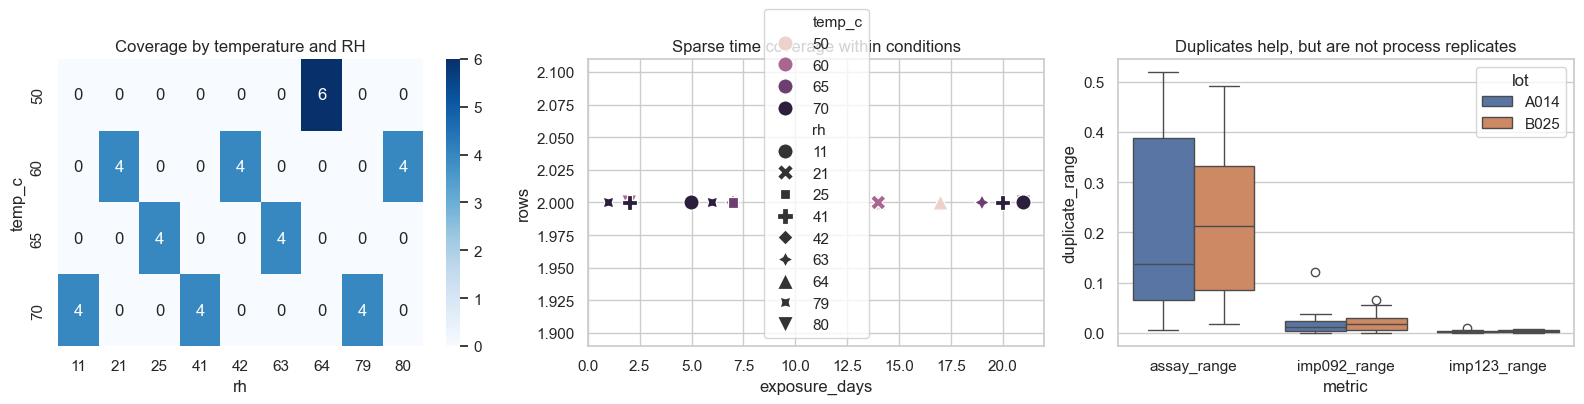

In [2]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
condition_counts = analysis_df.groupby(['temp_c','rh']).size().reset_index(name='rows')
sns.heatmap(condition_counts.pivot(index='temp_c', columns='rh', values='rows').fillna(0), annot=True, fmt='.0f', cmap='Blues', ax=axes[0])
axes[0].set_title('Coverage by temperature and RH')
time_counts = analysis_df.groupby(['temp_c','rh','exposure_days']).size().reset_index(name='rows')
sns.scatterplot(data=time_counts, x='exposure_days', y='rows', hue='temp_c', style='rh', s=120, ax=axes[1])
axes[1].set_title('Sparse time coverage within conditions')
range_df = analysis_df.melt(id_vars=['lot'], value_vars=['assay_range','imp092_range','imp123_range'], var_name='metric', value_name='duplicate_range')
sns.boxplot(data=range_df, x='metric', y='duplicate_range', hue='lot', ax=axes[2])
axes[2].set_title('Duplicates help, but are not process replicates')
plt.tight_layout()
plt.show()


## Limitations of the current dataset

The biggest limitation is that each formulation is represented by only one lot. That makes it difficult to distinguish true formulation differences from ordinary lot-to-lot variability. The formulation ranking is therefore useful, but not fully secure.

A second limitation is the sparse design. The study covers several temperatures, humidity levels, and exposure durations, but there are not many repeated observations within each specific condition pathway. This makes it hard to fit reliable kinetic models or to isolate interaction effects cleanly.

The duplicate measurements are valuable for checking analytical consistency, but they should not be treated as independent stability replicates. They tell us more about repeatability than about process-level variation under stress.

A final limitation is that the study is accelerated and focused on a narrow set of analytical endpoints. That is appropriate for early screening, but it cannot fully answer real-time shelf-life questions or broader product-quality questions on its own.

## What I would prioritise next

The highest-value improvement would be to test multiple independent lots per formulation. That would allow a much stronger statement about whether the observed differences are truly formulation-driven.

After that, I would increase the number of time points within each stress condition. This would help distinguish linear, curved, or early-peak degradation behaviour, especially for Impurity RRT 1.23.

I would also make the temperature and humidity design more balanced. A cleaner factorial structure would improve both interpretation and modelling, especially when trying to separate the effects of heat, moisture, and time.

If resources allowed, I would then add a small real-time or intermediate-condition study and broaden the measured quality attributes. That would make the conclusions more useful for practical development decisions rather than only for stress screening.
